# GOLEM Fast Spectrometer to Fast Cameras Comparison

This notebook loads and visualizes fast spectrometry data alongside fast camera data from the GOLEM tokamak, allowing for temporal comparison of diagnostics.

**Features:**
- Load fast spectrometry signals (especially WHOLE spectrum)
- Load fast camera data (Radial and Vertical)
- Generate comparative plots showing temporal correlations
- Visual analysis of plasma behavior across diagnostics

## Setup & Configuration

In [10]:
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from golem_data_loader import GolemDataLoader, SpectroscopyLine

# Default shot number
DEFAULT_SHOT = 50377

# Volume definitions (mm³)
VOLUME_SPEC = 172280       # Spectrometry volume
VOLUME_RADIAL = 42951      # Radial camera volume
VOLUME_VERTICAL = 13800.90625  # Vertical camera volume

# Color scheme for consistent visualization
COLORS = {
    'spectrum': '#2E86AB',      # Deep blue
    'camera_radial': '#A23B72', # Purple
    'camera_vertical': '#F18F01', # Orange
    'grid': '#CCCCCC'
}

# Figure styling
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
})


## Section 1: Data Loading Functions

In [11]:
def load_all_data(shot_number: int) -> dict:
    """
    Load fast spectrometry and fast camera data from GOLEM server.
    
    Args:
        shot_number: The GOLEM shot number
        
    Returns:
        Dictionary containing loaded data with keys:
        - 'spectrum': Fast spectrometry data
        - 'cameras': Fast camera data
        - 'shot': Shot number
    """
    print(f"\n{'='*70}")
    print(f"LOADING DATA FOR SHOT {shot_number}")
    print(f"{'='*70}\n")
    
    loader = GolemDataLoader(shot_number=shot_number)
    data_container = {'shot': shot_number}
    
    # Load fast spectrometry (WHOLE spectrum only)
    print("► Loading Fast Spectrometry (WHOLE spectrum)...")
    try:
        spec_data = loader.load_fast_spectrometry(lines=[SpectroscopyLine.WHOLE])
        data_container['spectrum'] = spec_data['Whole']
        print(f"  ✓ Loaded {len(data_container['spectrum'].time)} spectral data points")
        print(f"    Time range: {data_container['spectrum'].time[0]:.4f}s - {data_container['spectrum'].time[-1]:.4f}s")
        print(f"    Intensity: {data_container['spectrum'].intensity.min():.2f} - {data_container['spectrum'].intensity.max():.2f} a.u.")
    except Exception as e:
        print(f"  ✗ Error loading spectrometry: {e}")
        data_container['spectrum'] = None
    
    # Load fast camera data
    print("\n► Loading Fast Camera Data (Radial & Vertical)...")
    try:
        cameras = loader.load_fast_cameras()
        data_container['cameras'] = cameras
        for cam_name, cam_data in cameras.items():
            print(f"  ✓ {cam_name.capitalize()}: {cam_data.frames.shape[0]} frames @ {cam_data.frame_rate:.0f} fps")
            print(f"    Duration: {cam_data.time[-1]*1000:.2f} ms")
    except Exception as e:
        print(f"  ✗ Error loading cameras: {e}")
        data_container['cameras'] = None
    
    print()
    return data_container

## Section 2: Spectrometry Visualization

In [12]:
def plot_spectrometry(data_container: dict) -> None:
    """
    Plot fast spectrometry WHOLE spectrum over time.
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['spectrum'] is None:
        print("✗ No spectrometry data available")
        return
    
    print("► Generating Spectrometry Plot...")
    
    spectrum = data_container['spectrum']
    shot = data_container['shot']
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    # Plot spectrum
    ax.plot(spectrum.time * 1e3, spectrum.intensity * 10, 
            linewidth=1.5, color=COLORS['spectrum'], label='WHOLE Spectrum')
    
    # Styling
    ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Intensity (a.u.)', fontsize=12, fontweight='bold')
    ax.set_title(f'Fast Spectrometry - WHOLE Spectrum | Shot {shot}', 
                 fontsize=14, fontweight='bold', pad=15)
    ax.grid(True, alpha=0.3, linestyle='--', color=COLORS['grid'])
    ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Spectrometry plot displayed\n")

## Section 3: Fast Cameras Visualization

In [13]:
def plot_fast_cameras(data_container: dict, max_frames: int = 400) -> None:
    """
    Plot fast camera data as temporal sequences.
    
    Args:
        data_container: Dictionary containing loaded data
        max_frames: Maximum number of frames to display
    """
    if data_container['cameras'] is None or not data_container['cameras']:
        print("✗ No camera data available")
        return
    
    print(f"► Generating Fast Camera Plots (max {max_frames} frames)...")
    
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    # Create subplots for each camera
    fig, axes = plt.subplots(len(cameras), 1, figsize=(14, 4*len(cameras)))
    if len(cameras) == 1:
        axes = [axes]
    
    for ax, (cam_name, cam_data) in zip(axes, cameras.items()):
        # Limit frames for display
        n_frames = min(max_frames, cam_data.frames.shape[0])
        frames_subset = cam_data.frames[:n_frames]
        time_subset = cam_data.time[:n_frames] * 1e3
        
        # Reshape for display: (frames, height, width)
        if len(frames_subset.shape) == 3:
            display_data = np.mean(frames_subset, axis=2)  # Average RGB channels
        else:
            display_data = frames_subset
        
        # Transpose for proper visualization (time on x, spatial on y)
        im = ax.imshow(display_data.T, aspect='auto', cmap='gray', 
                       extent=[time_subset[0], time_subset[-1], 0, display_data.shape[1]],
                       interpolation='nearest', origin='lower')
        
        # Styling
        ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Spatial Position (pixels)', fontsize=12, fontweight='bold')
        ax.set_title(f'{cam_name.capitalize()} Fast Camera (80k fps) | Shot {shot}', 
                    fontsize=13, fontweight='bold')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Intensity (a.u.)')
    
    plt.tight_layout()
    plt.show()
    print(f"  ✓ Fast camera plots displayed\n")

## Section 4: Combined Comparison

## Section 5: Camera Temporal Averaging

In [14]:
def plot_camera_temporal_average(data_container: dict) -> None:
    """
    Plot per-frame pixel-averaged camera intensity over time.
    Averages all pixel values in each frame to create a temporal signal.
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['cameras'] is None or not data_container['cameras']:
        print("✗ No camera data available")
        return
    
    print("► Generating Camera Temporal Average Plots...")
    
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    fig, axes = plt.subplots(len(cameras), 1, figsize=(14, 4*len(cameras)))
    if len(cameras) == 1:
        axes = [axes]
    
    for ax, (cam_name, cam_data) in zip(axes, cameras.items()):
        # Get frames and average all pixels in each frame
        frames = cam_data.frames
        
        # Handle RGB channels if present
        if len(frames.shape) == 3:
            display_data = np.mean(frames, axis=2)  # Average RGB channels first
        else:
            display_data = frames
        
        # Apply ROI for vertical camera before averaging
        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]
        
        # Average over all spatial dimensions per frame (all pixels averaged for each frame)
        # This creates a single value per frame
        temporal_average = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        time_ms = cam_data.time * 1e3
        
        # Plot
        ax.plot(time_ms, temporal_average, linewidth=1.5, color=COLORS['camera_radial'], 
                label=f'{cam_name.capitalize()} - Pixel Average')
        
        # Styling
        ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_ylabel('Pixel-Averaged Intensity (a.u.)', fontsize=12, fontweight='bold')
        ax.set_title(f'{cam_name.capitalize()} Camera - Per-Frame Pixel Average | Shot {shot}', 
                    fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3, linestyle='--')
        ax.legend(loc='upper right', fontsize=11)
    
    plt.tight_layout()
    plt.show()
    print("  ✓ Camera temporal average plots displayed\n")

In [ ]:
def plot_comparison(data_container: dict) -> None:
    """
    Create a unified plot showing fast spectrometry (with LCS correction) and fast cameras.
    - Fast spectrometry: multiply by LCS, normalize 0-1
    - Fast cameras: discard pixels, average, normalize 0-1
    - Plot all signals on one graph
    
    Args:
        data_container: Dictionary containing loaded data
    """
    if data_container['spectrum'] is None or data_container['cameras'] is None:
        print("✗ Incomplete data for comparison (need both spectrum and cameras)")
        return
    
    print("► Generating Comparison Plot with LCS correction...")
    
    spectrum = data_container['spectrum']
    cameras = data_container['cameras']
    shot = data_container['shot']
    
    # Get reference time (camera start, which should be t=0)
    camera_ref_time = next(iter(cameras.values())).time[0]
    spec_start_time = spectrum.time[0]
    time_offset = spec_start_time - camera_ref_time
    
    print("\n  TIME DIAGNOSTICS:")
    print(f"  Time offset: {time_offset*1e3:.4f} ms")
    
    # Apply time offset correction to spectrum
    spectrum_time_corrected = spectrum.time - time_offset
    
    # Find common time range
    time_min = spectrum_time_corrected.min()
    time_max = spectrum_time_corrected.max()
    
    for cam_data in cameras.values():
        time_min = max(time_min, cam_data.time.min())
        time_max = min(time_max, cam_data.time.max())
    
    print(f"  Common time range: {time_min*1e3:.2f} - {time_max*1e3:.2f} ms")
    
    # Create common time grid at spectrometry resolution
    common_time = np.linspace(time_min, time_max, len(spectrum.time))
    common_time_ms = common_time * 1e3
    
    # Build LCS map from globals
    def build_lcs_map() -> dict:
        lcs_map = {}
        for key, value in globals().items():
            if not isinstance(key, str) or not key.startswith("LCS"):
                continue
            suffix = key[3:]
            if not suffix.isdigit():
                continue
            if len(suffix) == 2:
                start_ms = int(suffix[0])
                end_ms = int(suffix[1])
            elif len(suffix) == 3:
                start_ms = int(suffix[0])
                end_ms = int(suffix[1:])
            else:
                start_ms = int(suffix[:-2])
                end_ms = int(suffix[-2:])
            lcs_map[(start_ms, end_ms)] = float(value)
        return lcs_map
    
    # Interpolate spectrum to common time grid
    spectrum_interp = np.interp(common_time, spectrum_time_corrected, spectrum.intensity)
    
    # Apply LCS correction
    lcs_map = build_lcs_map()
    if lcs_map:
        print(f"\n  LCS CORRECTION:")
        print(f"  Found {len(lcs_map)} LCS values")
        time_bin_ms = 2.0
        bin_start = np.floor(common_time_ms / time_bin_ms) * time_bin_ms
        bin_end = bin_start + time_bin_ms
        lcs_factors = np.ones_like(spectrum_interp, dtype=float)
        for (start_ms, end_ms), lcs_value in lcs_map.items():
            mask = (bin_start == start_ms) & (bin_end == end_ms)
            if np.any(mask):
                lcs_factors[mask] = lcs_value
        spectrum_corrected = spectrum_interp * lcs_factors
    else:
        print("\n  No LCS values found, using uncorrected spectrum")
        spectrum_corrected = spectrum_interp
    
    # Normalize spectrum to 0-1
    spectrum_max = np.max(spectrum_corrected)
    if spectrum_max > 0:
        spectrum_normalized = spectrum_corrected / spectrum_max
    else:
        spectrum_normalized = spectrum_corrected
    
    print(f"  Spectrum normalized: max = {spectrum_max:.2f}")
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Plot normalized spectrum
    ax.plot(common_time_ms, spectrum_normalized,
            linewidth=2, color=COLORS['spectrum'], label='WHOLE Spectrum (LCS corrected)', alpha=0.8)
    
    # Process and plot camera signals
    for idx, (cam_name, cam_data) in enumerate(cameras.items()):
        # Prepare data
        frames = cam_data.frames
        if len(frames.shape) == 3:
            display_data = np.mean(frames, axis=2)  # Average RGB channels
        else:
            display_data = frames
        
        # Apply ROI (discard pixels) for vertical camera
        if cam_name == 'vertical':
            if display_data.ndim == 2:
                display_data = display_data[:, 301:561]
            elif display_data.ndim == 3:
                display_data = display_data[:, 301:561, :]
        
        # Average pixels per frame
        pixel_avg = np.mean(display_data, axis=tuple(range(1, display_data.ndim)))
        
        # Interpolate to common time grid
        camera_interp = np.interp(common_time, cam_data.time, pixel_avg)
        
        # Normalize to 0-1
        camera_max = np.max(camera_interp)
        if camera_max > 0:
            camera_normalized = camera_interp / camera_max
        else:
            camera_normalized = camera_interp
        
        print(f"  {cam_name.capitalize()} camera normalized: max = {camera_max:.2f}")
        
        # Plot
        color = COLORS['camera_vertical'] if idx > 0 else COLORS['camera_radial']
        ax.plot(common_time_ms, camera_normalized, linewidth=2,
                color=color, label=f'{cam_name.capitalize()} Camera', alpha=0.8)
    
    # Styling
    ax.set_xlabel('Time (ms)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Intensity (0-1)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='upper right', fontsize=11)
    ax.set_ylim(0, 1.05)
    
    plt.title(f'GOLEM Multi-Diagnostic Comparison | Shot {shot} (LCS-Corrected, 0-1 Normalized)', 
              fontsize=14, fontweight='bold', pad=15)
    fig.tight_layout()
    plt.show()
    print("\n  ✓ Comparison plot displayed\n")


## Section 5: Analysis Configuration & Execution

In [16]:
# ============================================================================
# CONFIGURE SHOT NUMBER HERE
# ============================================================================
SHOT_TO_ANALYZE = 50730


  # ← CHANGE THIS VALUE TO ANALYZE A DIFFERENT SHOT

2026-02-13 20:43:10,459 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma start time from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/PlasmaDetection/Results/t_plasma_start
2026-02-13 20:43:10,524 - golem_data_loader.golem_data_loader - INFO - Successfully loaded plasma end time from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/PlasmaDetection/Results/t_plasma_end



RUNNING ANALYSIS FOR SHOT 50730


LOADING DATA FOR SHOT 50730



2026-02-13 20:43:10,525 - golem_data_loader.golem_data_loader - INFO - Loaded plasma timing: 2.93 - 15.31 ms
2026-02-13 20:43:10,700 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Whole spectrometry from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastSpectrometry/DAS_raw_data_dir/ch6.csv
2026-02-13 20:43:10,707 - golem_data_loader.golem_data_loader - INFO - Whole: loaded 19999 rows, columns = ['    0', '0.002']
2026-02-13 20:43:10,708 - golem_data_loader.golem_data_loader - INFO - Loading Fast Camera (Radial) frames...


► Loading Fast Spectrometry (WHOLE spectrum)...
  ✓ Loaded 19999 spectral data points
    Time range: 0.0000s - 0.0400s
    Intensity: -0.00 - 5.08 a.u.

► Loading Fast Camera Data (Radial & Vertical)...


2026-02-13 20:43:10,766 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 1 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/1.png
2026-02-13 20:43:10,838 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 2 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/2.png
2026-02-13 20:43:10,894 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 3 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/3.png
2026-02-13 20:43:10,934 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 4 from http://golem.fjfi.cvut.cz/shots/50730/Diagnostics/FastCameras/Camera_Radial/Frames/4.png
2026-02-13 20:43:10,966 - golem_data_loader.golem_data_loader - INFO - Successfully loaded Fast Camera (Radial) frame 5 from http://golem.fjfi.c

  ✓ Radial: 1599 frames @ 80000 fps
    Duration: 19.98 ms
  ✓ Vertical: 1599 frames @ 80000 fps
    Duration: 19.98 ms

► Generating Comparison Plot...

  TIME DIAGNOSTICS (BEFORE CORRECTION):
  Spectrometry: t_start=0.0020 ms
  Radial: t_start=0.0000 ms
  Vertical: t_start=0.0000 ms

  TIME OFFSET: 0.0020 ms (2.00 µs)

  TIME DIAGNOSTICS (AFTER CORRECTION):
  Spectrometry: t_start=0.0000 ms, t_end=39.9980 ms
  Radial: t_start=0.0000 ms, t_end=19.9750 ms
  Vertical: t_start=0.0000 ms, t_end=19.9750 ms

  Common time range: 0.00 - 19.98 ms

  VOLUME NORMALIZATION:
  Spectrometry volume: 172,280 mm³
  Radial camera volume: 42,951 mm³
  Vertical camera volume: 13,800.90625 mm³


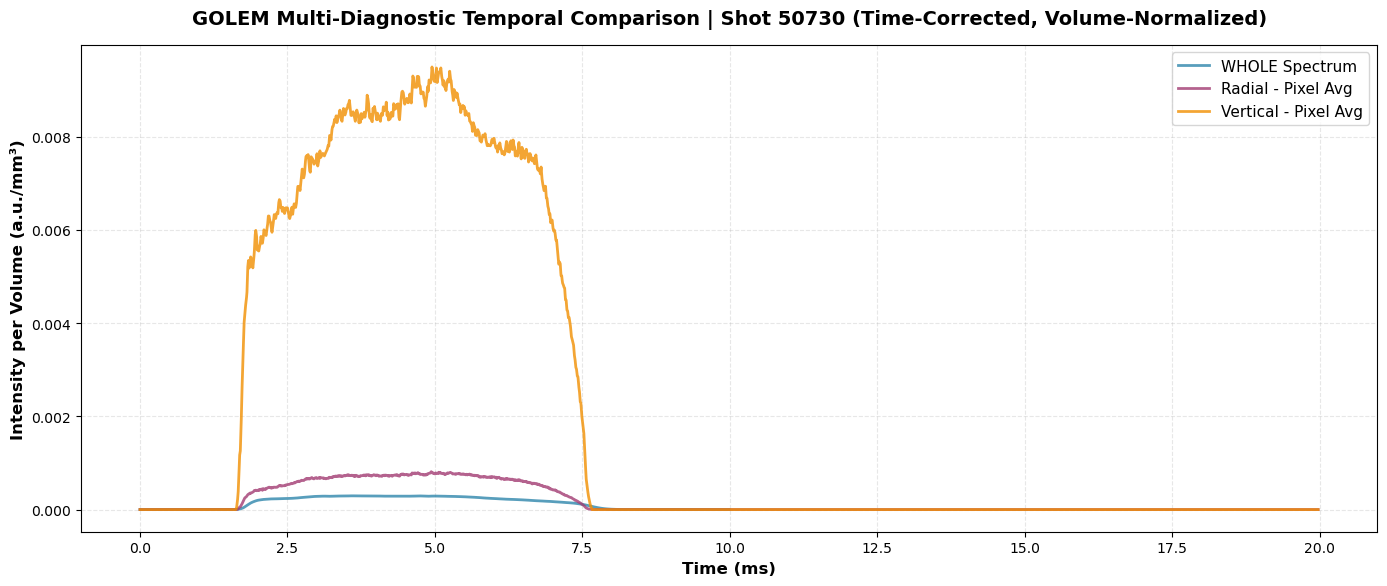


  ✓ Comparison plot displayed

ANALYSIS COMPLETE



In [17]:
# Load data and generate combined comparison plot
print(f"\n{'='*70}")
print(f"RUNNING ANALYSIS FOR SHOT {SHOT_TO_ANALYZE}")
print(f"{'='*70}\n")

data = load_all_data(SHOT_TO_ANALYZE)
plot_comparison(data)

print(f"{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}\n")

► Generating Comparison Plot...

  TIME DIAGNOSTICS (BEFORE CORRECTION):
  Spectrometry: t_start=0.0020 ms
  Radial: t_start=0.0000 ms
  Vertical: t_start=0.0000 ms

  TIME OFFSET: 0.0020 ms (2.00 µs)

  TIME DIAGNOSTICS (AFTER CORRECTION):
  Spectrometry: t_start=0.0000 ms, t_end=39.9980 ms
  Radial: t_start=0.0000 ms, t_end=19.9750 ms
  Vertical: t_start=0.0000 ms, t_end=19.9750 ms

  Common time range: 0.00 - 19.98 ms

  VOLUME NORMALIZATION:
  Spectrometry volume: 172,280 mm³
  Radial camera volume: 42,951 mm³
  Vertical camera volume: 13,800.90625 mm³


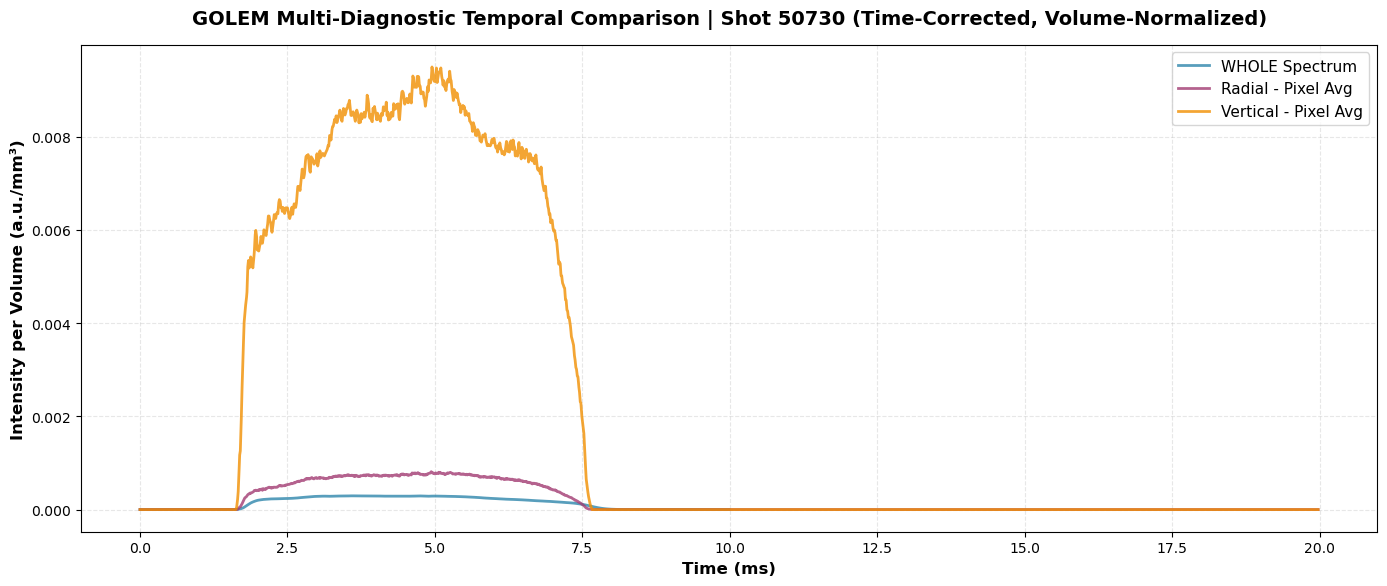


  ✓ Comparison plot displayed



In [18]:
# Generate combined comparison visualization
plot_comparison(data)

## Done!

Change the `SHOT_TO_ANALYZE` value in the configuration cell above and run the analysis cell to generate all graphs for your desired shot.